# Proyección de Coordenadas de Sitios de Ensayos Clínicos para Mapeo con PROC GPROJECT


## Resumen Ejecutivo

Un equipo de operaciones clínicas necesita graficar la huella geográfica de un ensayo de Fase III con múltiples sitios en un mapa plano. Este cuaderno genera coordenadas sintéticas de latitud/longitud para sitios del ensayo agrupados alrededor de cinco centros regionales de Estados Unidos, y luego usa **PROC GPROJECT** para convertir las coordenadas esféricas en valores cartesianos X/Y usando tres métodos de proyección (Albers de área equivalente, cónica conforme de Lambert con paralelos estándar personalizados y recorte regional, y Gnomónica centrada en el territorio continental de Estados Unidos), ilustrando cómo la elección de la proyección y el recorte afectan un mapa de sitios.


## Fuentes de Datos

| Dataset | Filas | Variables Clave | Descripción |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 centros x 12 sitios) | `site_id` (ID $8), `region` ($11), `x` (longitud, grados, positivo hacia el este), `y` (latitud, grados), `enroll` (sujetos inscritos), `segment` (id de segmento del mapa) | Ubicaciones sintéticas de sitios de un ensayo clínico de Fase III dispersas alrededor de cinco centros regionales de Estados Unidos (Oeste, Medio Oeste, Noreste, Sur, Sureste) usando variación aleatoria `rand('normal')` y conteos de inscripción `rand('poisson')` |


# Proyección de Coordenadas de Sitios de Ensayos Clínicos con PROC GPROJECT

Cuando un patrocinador ejecuta un ensayo de Fase III geográficamente disperso, el grupo de operaciones clínicas a menudo quiere un solo mapa que muestre cada sitio de investigación, dimensionado o coloreado según la inscripción. Las ubicaciones de los sitios llegan como **pares de longitud/latitud**, pero un mapa plano necesita **coordenadas planares X/Y**. `PROC GPROJECT` realiza esa conversión de esférico a cartesiano, aplicando una proyección cartográfica para que las distancias y las áreas se representen de forma sensata.

En este cuaderno:

1. Generamos coordenadas sintéticas de sitios agrupadas alrededor de cinco centros regionales de Estados Unidos.
2. Aplicamos la proyección predeterminada **Albers de área equivalente**.
3. Aplicamos una proyección **cónica conforme de Lambert** con paralelos estándar personalizados y recorte al territorio continental de Estados Unidos.
4. Aplicamos una proyección **Gnomónica** centrada en el punto medio geográfico del país, conservando las coordenadas originales con `ASIS`.

Todo es autocontenido: sin archivos externos, sin red.


## Paso 1 — Generar coordenadas sintéticas de sitios del ensayo

Sembramos el generador de números aleatorios con `call streaminit` para reproducibilidad, y luego ubicamos 12 sitios alrededor de cada una de cinco ciudades centro regionales. Las longitudes se almacenan en grados positivos hacia el este (negativas para el hemisferio occidental) y las latitudes en grados. Cada fila también lleva un conteo de inscripción y una variable `segment` (GPROJECT conserva las columnas que no son de coordenadas a través de la proyección).


In [1]:
DATOS trial_sites;
    LLAMAR streaminit(20260531);
    LONGITUD site_id $8 region $11;
    /* Cinco centros regionales de EE. UU.: longitud (este+), latitud */
    ARREGLO clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    ARREGLO clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    HACER hub = 1 HASTA 5;
        SI hub = 1 ENTONCES region = 'Oeste';
        SINO SI hub = 2 ENTONCES region = 'Medio Oeste';
        SINO SI hub = 3 ENTONCES region = 'Noreste';
        SINO SI hub = 4 ENTONCES region = 'Sur';
        SINO region = 'Sureste';
        HACER s = 1 HASTA 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* longitud, grados */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* latitud, grados */
            enroll  = round(rand('poisson', 60));           /* sujetos inscritos */
            segment = 1;
            SALIDA;
        END;
    END;
    ELIMINAR hub s;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=trial_sites(obs=10) ETIQUETA;
    ETIQUETA site_id="ID del Sitio" region="Región" x="Longitud" y="Latitud"
          enroll="Inscritos" segment="Segmento";
    TÍTULO "Muestra de Sitios Sintéticos del Ensayo Clínico (lon/lat sin Proyectar)";
EJECUTAR;


                        Muestra de Sitios Sintéticos del Ensayo Clínico (lon/lat sin Proyectar)                         

  Obs  ID del Sitio   Región         Longitud        Latitud  Inscritos  Segmento
    1  S101          Oeste    -121.6437232216  37.7677668495         65         1
    2  S102          Oeste    -120.7384024716  37.5083287903         61         1
    3  S103          Oeste    -121.5133780284  37.8633933883         72         1
    4  S104          Oeste    -121.2086817368  38.7723343392         68         1
    5  S105          Oeste    -121.0499572297   37.175813806         54         1
    6  S106          Oeste    -124.0531899967   35.778231667         72         1
    7  S107          Oeste    -120.9370181032  39.0576714397         64         1
    8  S108          Oeste    -126.8495029747  36.6474680375         55         1
    9  S109          Oeste     -123.475989897  37.1427965254         56         1
   10  S110          Oeste     -122.579780071   36.9315336


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Paso 2 — Proyección predeterminada Albers de área equivalente

La proyección cónica de área equivalente **Albers** es la predeterminada de GPROJECT y una opción sensata para un mapa a escala de país donde importa preservar el *área relativa* (por ejemplo, comparar el tamaño de las áreas de captación regionales).

Como nuestras coordenadas se almacenan en **grados** con **longitud positiva hacia el este**, especificamos las opciones `DEGREE` y `EASTLONG`. La sentencia `ID` nombra la variable que identifica de forma única a cada unidad; las coordenadas planares proyectadas se escriben de vuelta en `x` e `y` en el dataset `OUT=`.


In [2]:
PROCEDIMIENTO GPROJECT DATOS=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=sites_albers(obs=10) ETIQUETA;
    ETIQUETA site_id="ID del Sitio" region="Región" x="X Proyectada" y="Y Proyectada"
          enroll="Inscritos" segment="Segmento";
    TÍTULO "Sitios del Ensayo Tras la Proyección Albers de Áreas Iguales (X/Y planar)";
EJECUTAR;


                        Muestra de Sitios Sintéticos del Ensayo Clínico (lon/lat sin Proyectar)                         

                       Sitios del Ensayo Tras la Proyección Albers de Áreas Iguales (X/Y planar)                        

  Obs  ID del Sitio   Región   X Proyectada  Y Proyectada  Inscritos  Segmento
    1  S101          Oeste     -0.346124731  0.0516986079         65         1
    2  S102          Oeste    -0.3353644139  0.0440400181         61         1
    3  S103          Oeste    -0.3439609675  0.0528501365         72         1
    4  S104          Oeste    -0.3357513354   0.067213083         68         1
    5  S105          Oeste    -0.3410170723  0.0394882801         54         1
    6  S106          Oeste    -0.3879364507  0.0273340733         72         1
    7  S107          Oeste    -0.3309127579  0.0711146305         64         1
    8  S108          Oeste    -0.4204191205  0.0538118922         55         1
    9  S109          Oeste     -0.373326801  


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Paso 3 — Proyección cónica conforme de Lambert con paralelos personalizados y recorte

La proyección cónica conforme de **Lambert** preserva la *forma y los ángulos locales*, lo cual es preferible cuando el mapa se usa para navegación o para superponer características direccionales. Para el territorio continental de Estados Unidos, los paralelos estándar cerca de 33 grados N y 45 grados N son convencionales, así que los fijamos explícitamente con `PARALLEL1=` y `PARALLEL2=`.

También restringimos el mapa a la ventana continental de Estados Unidos usando las opciones de recorte `LATMIN=`, `LATMAX=`, `LONGMIN=` y `LONGMAX=`. Cualquier sitio que caiga fuera de este cuadro de latitud/longitud se descarta antes de la proyección, por lo que el número de observaciones de salida puede ser menor que el de entrada.


In [3]:
PROCEDIMIENTO GPROJECT DATOS=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=sites_lambert(obs=10) ETIQUETA;
    ETIQUETA site_id="ID del Sitio" region="Región" x="X Proyectada" y="Y Proyectada"
          enroll="Inscritos" segment="Segmento";
    TÍTULO "Sitios del Ensayo Tras la Proyección Conforme de Lambert (recortado al territorio continental de Estados Unidos)";
EJECUTAR;


                       Sitios del Ensayo Tras la Proyección Albers de Áreas Iguales (X/Y planar)                        

    Sitios del Ensayo Tras la Proyección Conforme de Lambert (recortado al territorio continental de Estados Unidos)    

  Obs  ID del Sitio   Región   X Proyectada  Y Proyectada  Inscritos  Segmento
    1  S101          Oeste    -0.3473024124  0.0279382533         65         1
    2  S102          Oeste    -0.3365626234  0.0201991247         61         1
    3  S103          Oeste    -0.3451238364  0.0290365995         72         1
    4  S104          Oeste    -0.3367881094  0.0430616123         68         1
    5  S105          Oeste    -0.3422656751  0.0158037156         54         1
    6  S106          Oeste    -0.3894389642  0.0046370991         72         1
    7  S107          Oeste    -0.3319086764  0.0468276119         64         1
    8  S109          Oeste    -0.3746144745  0.0248234546         56         1
    9  S110          Oeste    -0.3638098935  


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Paso 4 — Proyección Gnomónica centrada en el país, conservando los originales

La proyección azimutal **Gnomónica** representa cada círculo máximo como una línea recta, lo cual es útil cuando se quiere razonar sobre la ruta más corta entre sitios (por ejemplo, planificar la ruta de viaje de visita de un monitor). La distorsión crece con la distancia al polo de la proyección, así que centramos el polo en el punto medio geográfico del territorio continental de Estados Unidos con `POLELAT=39` y `POLELONG=-98`.

La opción `ASIS` le indica a GPROJECT que conserve las coordenadas originales sin proyectar junto con los valores proyectados, de modo que el dataset de salida lleva tanto las coordenadas planares `X`/`Y` como las de origen `LONG`/`LAT` — útil para volver a unir las métricas de inscripción a cualquiera de los dos espacios de coordenadas.

La sentencia `PARMENTRY` se muestra como una forma alternativa de proporcionar los parámetros de proyección como sobrescrituras clave=valor.


In [4]:
PROCEDIMIENTO GPROJECT DATOS=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=sites_gnomon(obs=10) ETIQUETA;
    ETIQUETA site_id="ID del Sitio" region="Región" x="X Proyectada" y="Y Proyectada"
          enroll="Inscritos" segment="Segmento";
    TÍTULO "Sitios del Ensayo Tras la Proyección Gnomónica (ASIS conserva LONG/LAT originales)";
EJECUTAR;


    Sitios del Ensayo Tras la Proyección Conforme de Lambert (recortado al territorio continental de Estados Unidos)    

                   Sitios del Ensayo Tras la Proyección Gnomónica (ASIS conserva LONG/LAT originales)                   

  Obs  ID del Sitio   Región   X Proyectada   Y Proyectada  Inscritos  Segmento             LONG            LAT
    1  S101          Oeste    -0.3343477981   0.0213614461         65         1  -121.6437232216  37.7677668495
    2  S102          Oeste    -0.3221611694   0.0134152735         61         1  -120.7384024716  37.5083287903
    3  S103          Oeste    -0.3319480803   0.0225717184         72         1  -121.5133780284  37.8633933883
    4  S104          Oeste    -0.3230855797   0.0375741352         68         1  -121.2086817368  38.7723343392
    5  S105          Oeste    -0.3283677206   0.0086308769         54         1  -121.0499572297   37.175813806
    6  S106          Oeste    -0.3813558012  -0.0046248781         72         1  -12


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Paso 5 — Representar el mapa de sitios proyectado

Todo el sentido de proyectar es dibujar el mapa. Llevamos el dataset `OUT=` de Albers directamente a **PROC SGPLOT**, graficando las coordenadas planares `X`/`Y` y coloreando cada marcador según `region`. Como la proyección preservó la geografía relativa, los cinco grupos de centros caen en las esquinas esperadas del gráfico — Oeste a la izquierda, Noreste arriba a la derecha, Sur y Sureste a lo largo de la parte inferior — dándole a operaciones clínicas la huella fiel al área descrita en el resumen ejecutivo.


                   Sitios del Ensayo Tras la Proyección Gnomónica (ASIS conserva LONG/LAT originales)                   




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


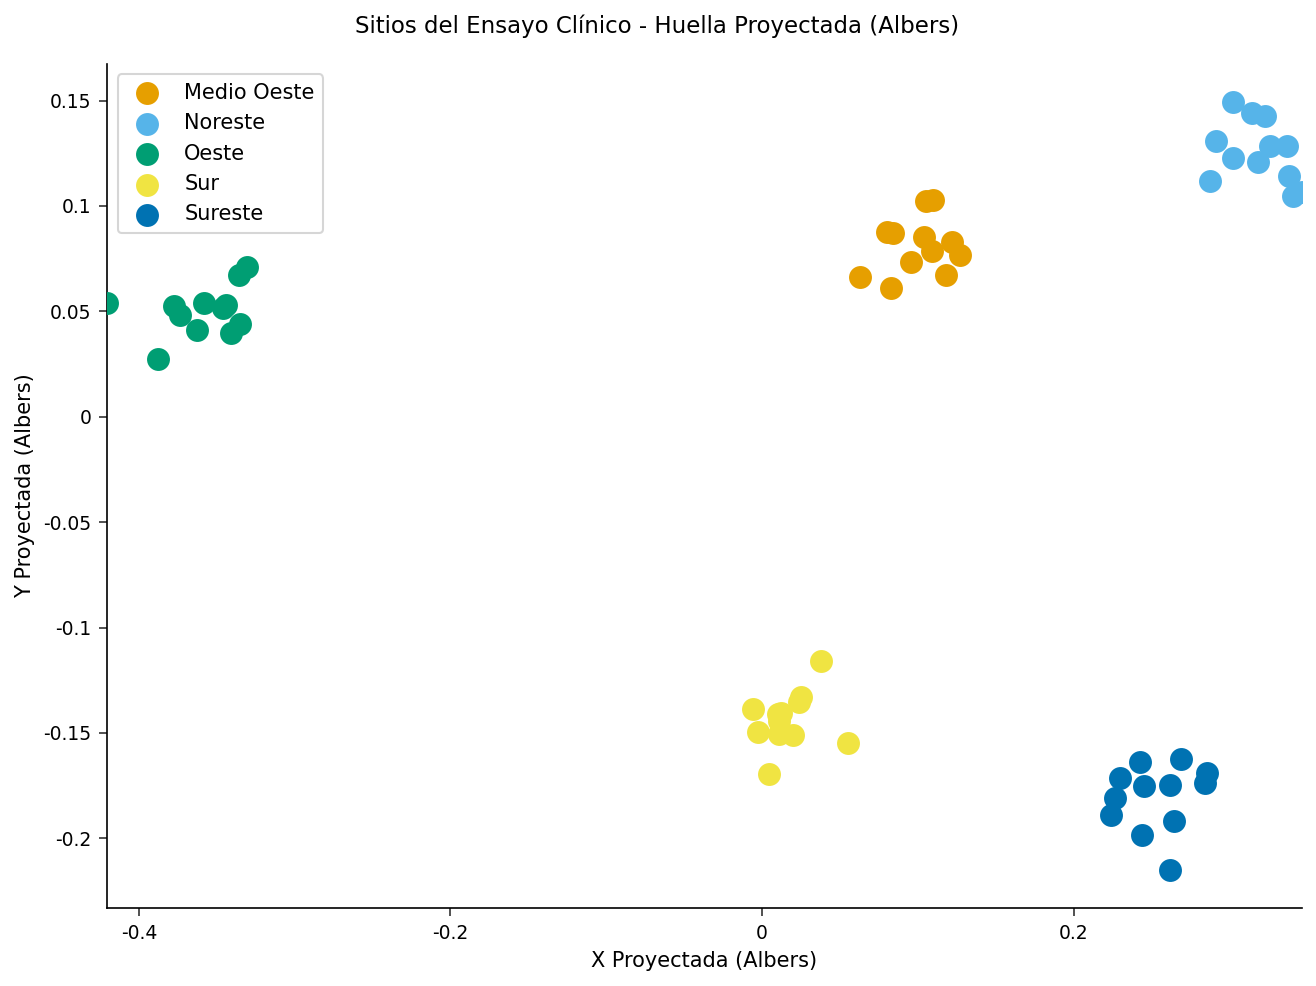

In [5]:
PROCEDIMIENTO SGPLOT DATOS=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS ETIQUETA='X Proyectada (Albers)';
    YAXIS ETIQUETA='Y Proyectada (Albers)';
    TÍTULO 'Sitios del Ensayo Clínico - Huella Proyectada (Albers)';
EJECUTAR;


## Interpretación de los resultados

- **Albers (Paso 2)** transformó los 60 sitios en coordenadas planares preservando el área relativa — los grupos Oeste, Medio Oeste, Noreste, Sur y Sureste mantienen su huella espacial proporcional, lo cual es la base correcta para un mapa de calor de inscripción fiel al área.
- **Lambert con recorte (Paso 3)** preservó la forma local y, al aplicar la ventana `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, descartó los sitios sintéticos que se dispersaron fuera del territorio continental de Estados Unidos — aquí el conteo bajó de 60 a 58, por lo que las dos coordenadas fuera de la cuadrícula que de otro modo estirarían el mapa se eliminaron antes de la proyección.
- **Gnomónica con `ASIS` (Paso 4)** centró la proyección en el interior del país y, gracias a `ASIS`, produjo un dataset que lleva tanto las coordenadas proyectadas `X`/`Y` como las originales `LONG`/`LAT`. Los círculos máximos aparecen como líneas rectas, por lo que las distancias en línea recta en este mapa aproximan las verdaderas rutas más cortas entre sitios.
- **La huella representada (Paso 5)** confirma que la proyección funcionó: al graficar `X`/`Y` de Albers por región, los cinco grupos de centros caen en las esquinas esperadas del plano, el mapa de sitios fiel al área que prometía el resumen ejecutivo.

**Conclusión para operaciones clínicas:** la proyección no es cosmética. Elija **Albers** para densidad de inscripción fiel al área, **Lambert** para superposiciones fieles a la forma con recorte regional, y **Gnomónica** cuando la distancia de viaje entre sitios impulsa el análisis. Como muestra el Paso 5, el dataset proyectado `OUT=` se conecta directamente a PROC SGPLOT (o PROC GMAP) para representar el mapa final de sitios.
